In [2]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 
# sklearn preprocessing for dealing with categorical variables
from sklearn.preprocessing import LabelEncoder
# File system manangement
import os
# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')
# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
app_train = pd.read_csv("D:\MyDownload\home-credit-default-risk\\application_train.csv")
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
app_test = pd.read_csv('D:\MyDownload\home-credit-default-risk\\application_test.csv')
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
4,100038,Cash loans,M,Y,N,1,180000.0,625500.0,32067.0,625500.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

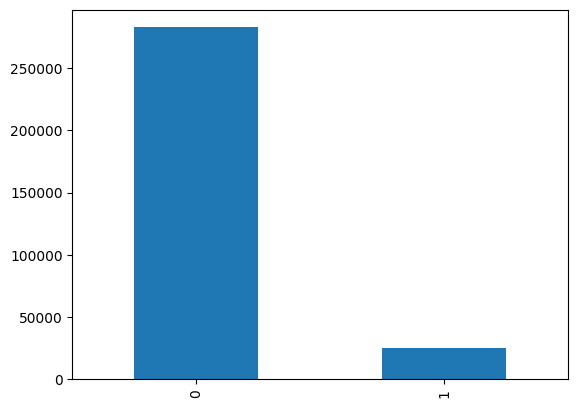

In [5]:
app_train['TARGET'].value_counts().plot(kind='bar')

# examine missing value

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


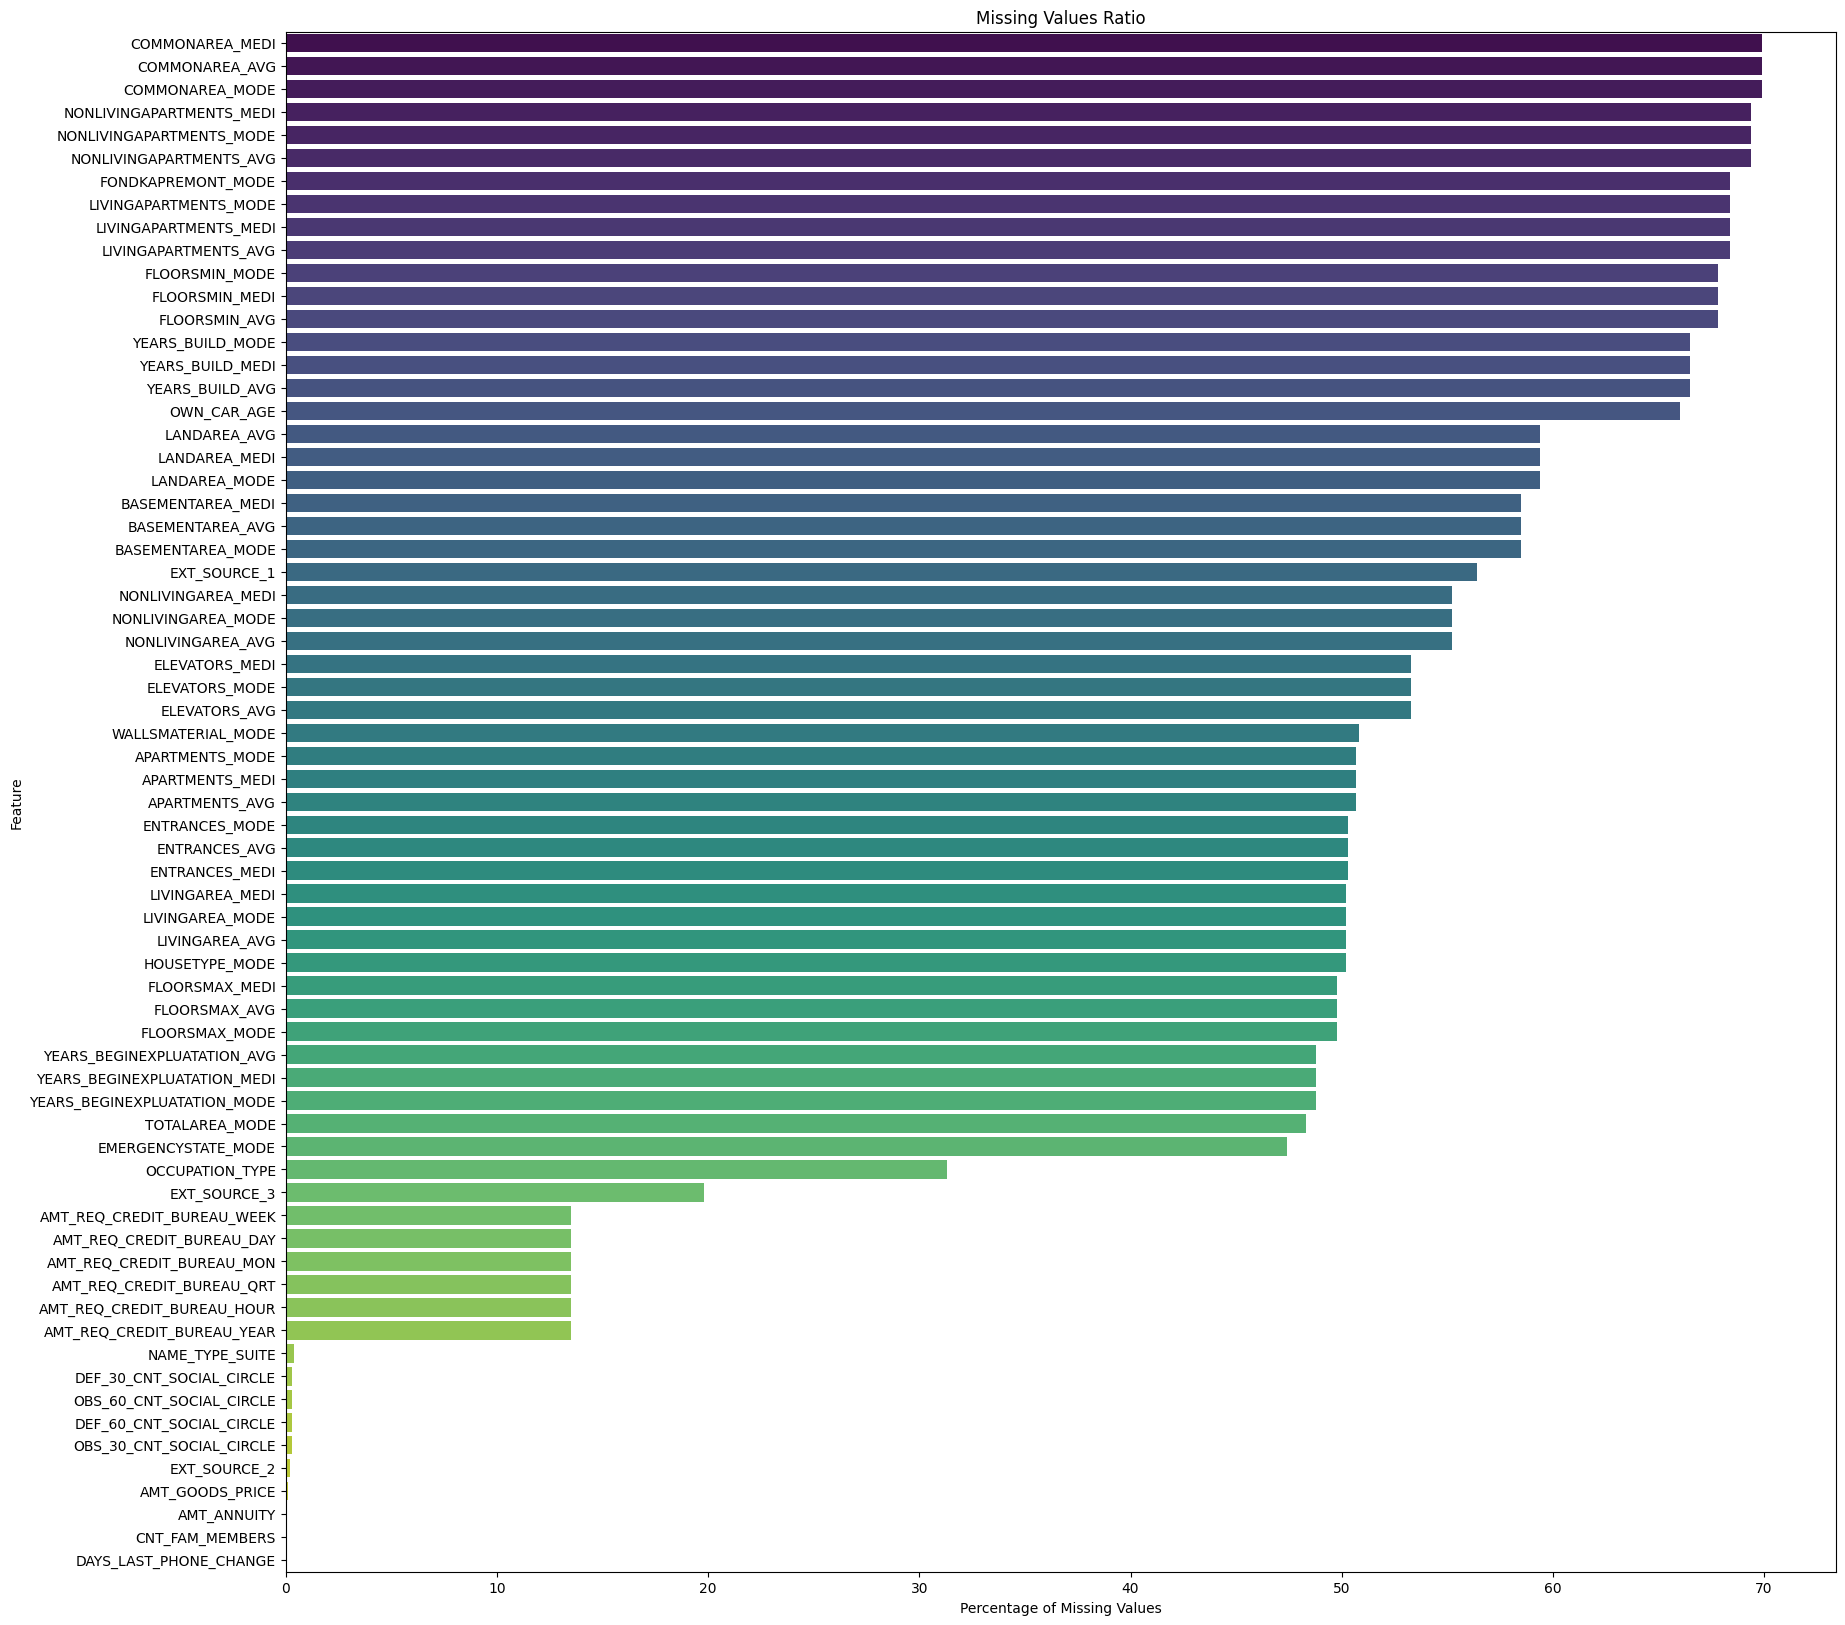

In [6]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()
        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)
        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")
        # Return the dataframe with missing information
        return mis_val_table_ren_columns
missing_values = missing_values_table(app_train)
plt.figure(figsize=(20, 20))
sns.barplot(x='% of Total Values', y=missing_values.index, data=missing_values, palette='viridis')
plt.xlabel('Percentage of Missing Values')
plt.ylabel('Feature')
plt.title('Missing Values Ratio')
plt.show()

In [7]:
# Identify continuous and discrete columns in app_train
continuous_cols = app_train.select_dtypes(include=['float64']).columns.tolist()
discrete_cols = app_train.select_dtypes(include=['int64']).columns.tolist()
categorial_cols = app_train.select_dtypes(include=['object']).columns.tolist()
print("num of categorial columns: ", len(categorial_cols))
print("num of continuous columns: ", len(continuous_cols))
print("num of discrete columns: ", len(discrete_cols))
missing_values = missing_values_table(app_train[discrete_cols])
app_discrete = app_train[discrete_cols].copy()
app_discrete.head()

num of categorial columns:  16
num of continuous columns:  65
num of discrete columns:  41
Your selected dataframe has 41 columns.
There are 0 columns that have missing values.


,SK_ID_CURR,TARGET,CNT_CHILDREN,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,...,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21
0,100002,1,0,-9461,-637,-2120,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
1,100003,0,0,-16765,-1188,-291,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
2,100004,0,0,-19046,-225,-2531,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,100006,0,0,-19005,-3039,-2437,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
4,100007,0,0,-19932,-3038,-3458,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


# Construct time-related variable, and describe it

In [8]:
app_discrete['age'] = app_discrete['DAYS_BIRTH'] / -365
app_discrete['years_employed'] = app_discrete['DAYS_EMPLOYED'] / -365
app_discrete['years_change id'] = app_discrete['DAYS_ID_PUBLISH'] / -365
print(app_discrete['age'].describe())
print(app_discrete['years_employed'].describe())
print(app_discrete['years_change id'].describe())

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: age, dtype: float64
count    307511.000000
mean       -174.835742
std         387.056895
min       -1000.665753
25%           0.791781
50%           3.323288
75%           7.561644
max          49.073973
Name: years_employed, dtype: float64
count    307511.000000
mean          8.203294
std           4.135481
min          -0.000000
25%           4.712329
50%           8.915068
75%          11.778082
max          19.717808
Name: years_change id, dtype: float64


the deleted rows:  55376
the deleted rows:  0


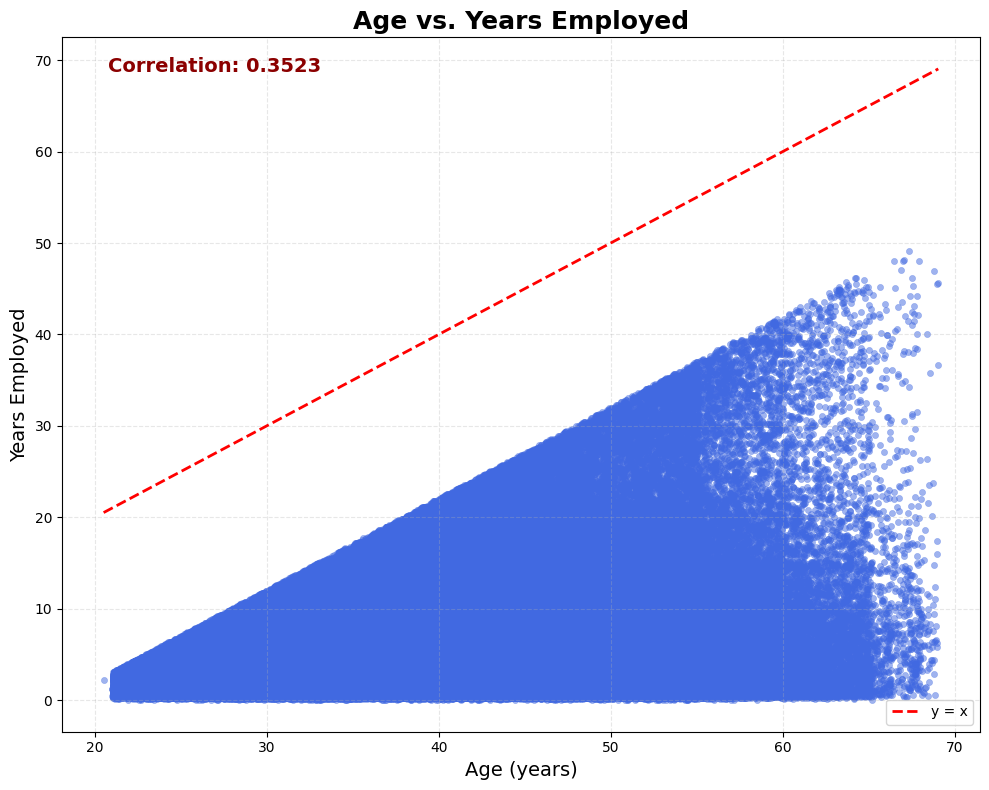

In [9]:
app_discrete_normal = app_discrete[app_discrete['years_employed']>0]
print('the deleted rows: ', app_discrete.shape[0] - app_discrete_normal.shape[0])
temp_rows = app_discrete_normal.shape[0]
app_discrete_normal = app_discrete_normal[app_discrete_normal['age']>20]
print('the deleted rows: ', temp_rows - app_discrete_normal.shape[0])
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='age', 
    y='years_employed', 
    data=app_discrete_normal, 
    alpha=0.5, 
    s=20, 
    color='royalblue', 
    edgecolor=None
)
plt.title('Age vs. Years Employed', fontsize=18, fontweight='bold')
# Add y=x reference line
min_val = app_discrete_normal['age'].min()
max_val = max(app_discrete_normal['age'].max(), app_discrete_normal['years_employed'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='y = x')
plt.legend()
plt.xlabel('Age (years)', fontsize=14)
plt.ylabel('Years Employed', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
corr = app_discrete_normal[['age', 'years_employed']].corr().iloc[0, 1]
plt.annotate(f'Correlation: {corr:.4f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=14, color='darkred', fontweight='bold')
plt.show()


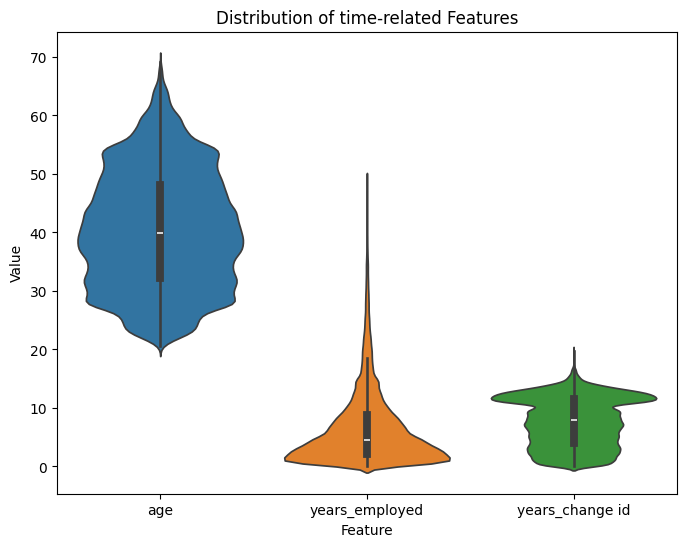

In [10]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=app_discrete_normal[['age','years_employed', 'years_change id']])
plt.title('Distribution of time-related Features')
plt.xlabel('Feature')
plt.ylabel('Value')
plt.show()

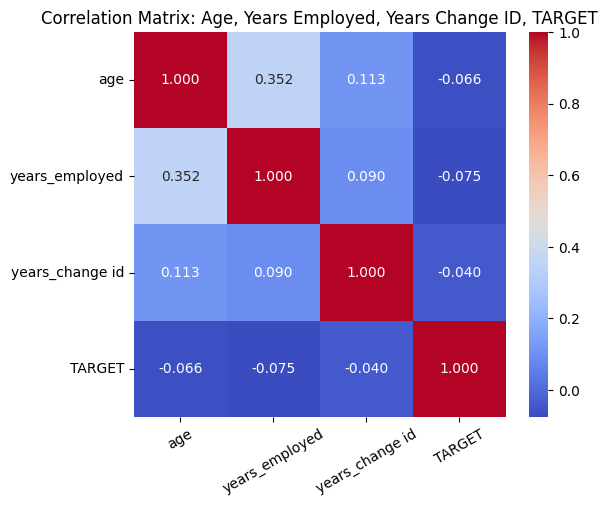

In [11]:
# 计算 age, years_employed, years_change id 与 TARGET 的相关性，并两两相关性
corr_matrix = app_discrete_normal[['age', 'years_employed', 'years_change id', 'TARGET']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlation Matrix: Age, Years Employed, Years Change ID, TARGET')
plt.xticks(rotation=30)
plt.show()

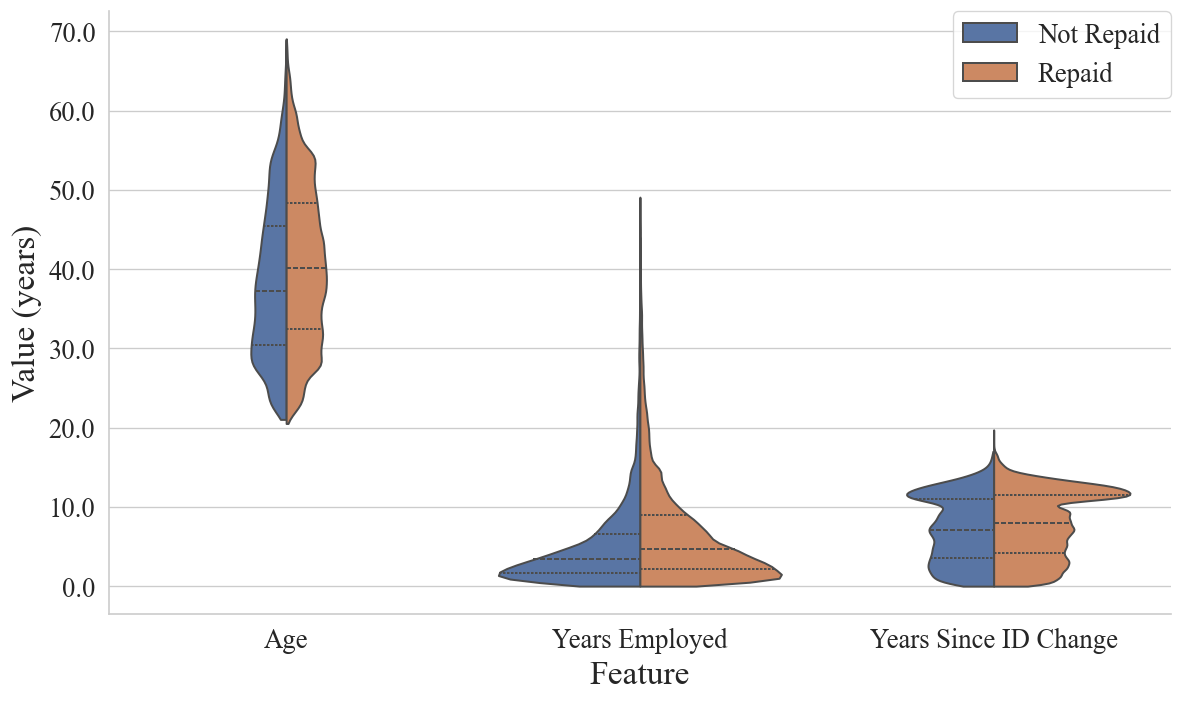

In [42]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Times New Roman'
df = app_discrete_normal.copy()
df = df.rename(columns={'years_change id': 'years_change_id'})
target_map = {0: 'Repaid', 1: 'Not Repaid'}
if df['TARGET'].dtype != 'object':
    if set(df['TARGET'].unique()).issubset(set(target_map.keys())):
        df['TARGET'] = df['TARGET'].map(target_map)
melted = df.melt(
    id_vars='TARGET',
    value_vars=['age', 'years_employed', 'years_change_id'],
    var_name='Feature',
    value_name='Value'
)
order = ['age', 'years_employed', 'years_change_id']
melted['Feature'] = pd.Categorical(melted['Feature'], categories=order, ordered=True)
sns.set_context('paper', font_scale=1.2)
plt.figure(figsize=(10, 6))
ax = sns.violinplot(
    x='Feature', y='Value', hue='TARGET', data=melted,
    split=True, inner='quartile', linewidth=1.2, cut=0
)
ax.set_xticklabels(['Age', 'Years Employed', 'Years Since ID Change'],fontsize=16)
ax.set_yticklabels(ax.get_yticks(), fontsize=16)
ax.set_xlabel('Feature', fontsize=20)
ax.set_ylabel('Value (years)',fontsize=20)  
#ax.set_title('Distribution of Time-related Features by Target')
leg = ax.legend(loc='upper right', borderaxespad=0, fontsize=16)
sns.despine()
plt.tight_layout()
# plt.savefig('violin_time_features_by_target.png', bbox_inches='tight')
# plt.savefig('violin_time_features_by_target.pdf', bbox_inches='tight')
plt.show()